In [158]:
import pandas as pd 
import numpy as np


In [159]:
df = pd.read_csv("StudentsPerformance.csv")  


In [160]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [161]:
df.shape

(1000, 8)

In [163]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data cleaning

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [165]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [166]:
# Convert columns to appropriate data types if necessary
df['math score'] = pd.to_numeric(df['math score'], errors='coerce')
df['reading score'] = pd.to_numeric(df['reading score'], errors='coerce')
df['writing score'] = pd.to_numeric(df['writing score'], errors='coerce')


In [167]:
df.duplicated().sum()

np.int64(0)

In [168]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

## 2. EDA

In [169]:
import seaborn as sns
import matplotlib.pyplot as plt

In [170]:
df[['math score', 'reading score', 'writing score']].describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000



Score Statistics:
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


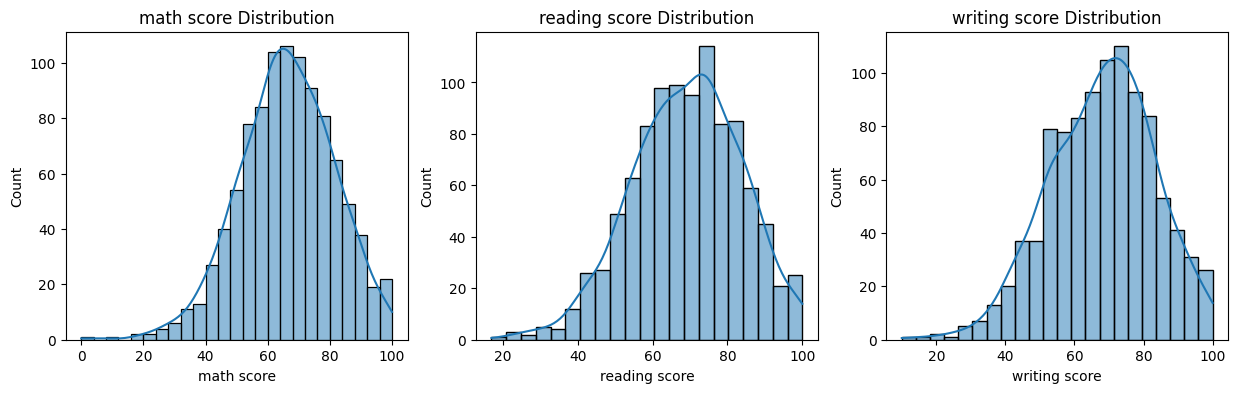

In [171]:
# 2.1 Numerical Analysis
print("\nScore Statistics:")
print(df[['math score', 'reading score', 'writing score']].describe())

plt.figure(figsize=(15, 4))
for i, col in enumerate(['math score', 'reading score', 'writing score'], 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')
plt.show()

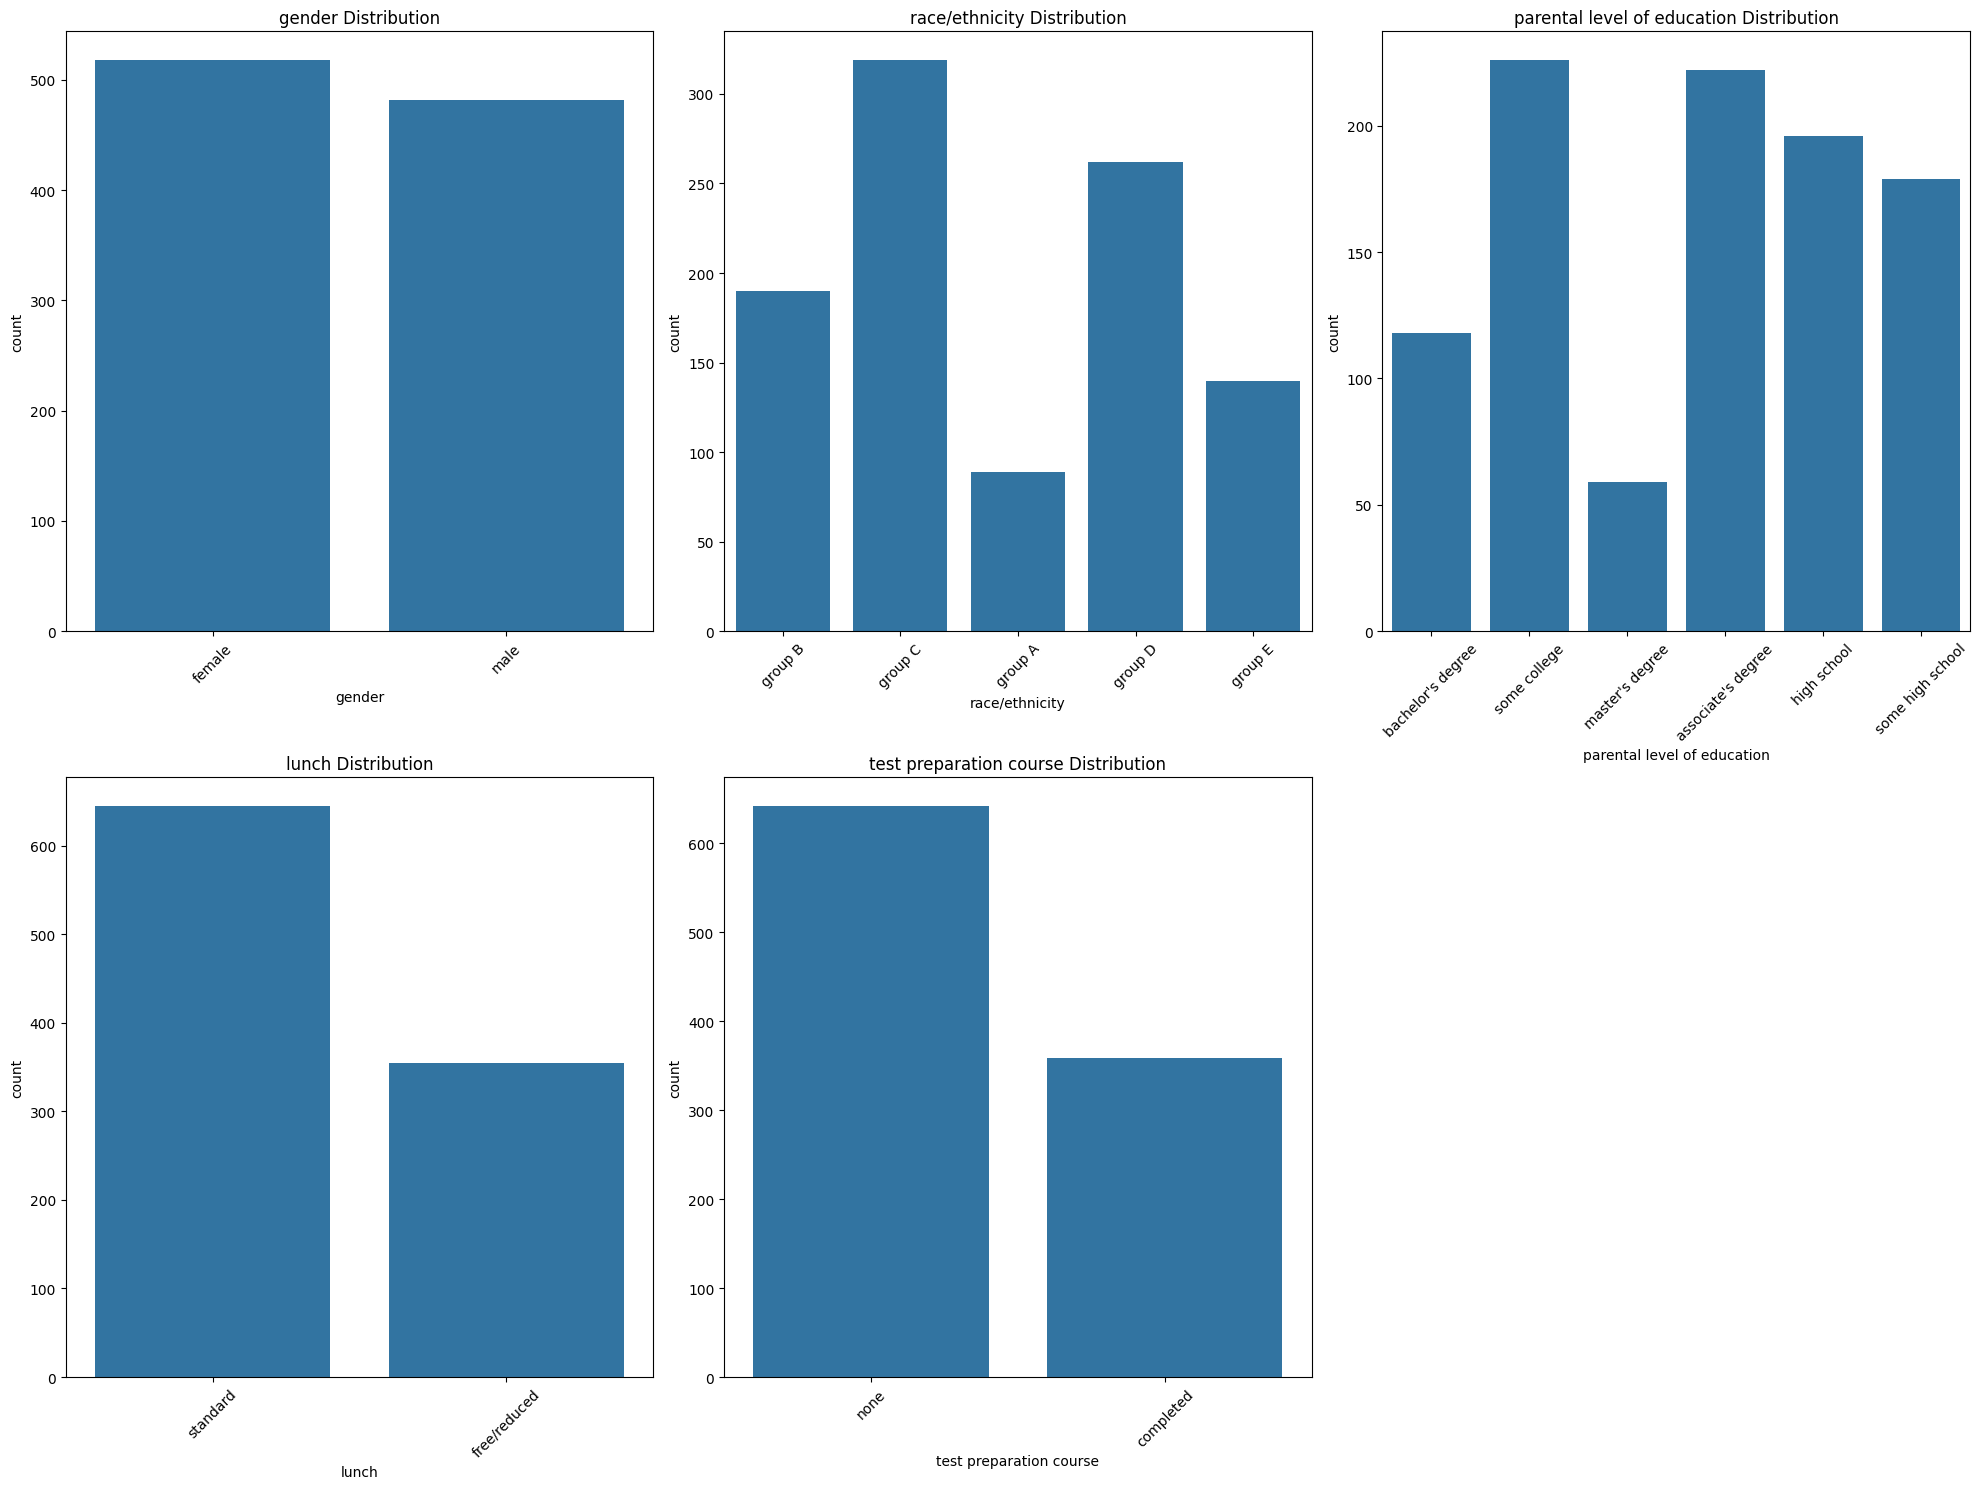

In [172]:
# 2.2 Categorical Analysis
cat_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, data=df)
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

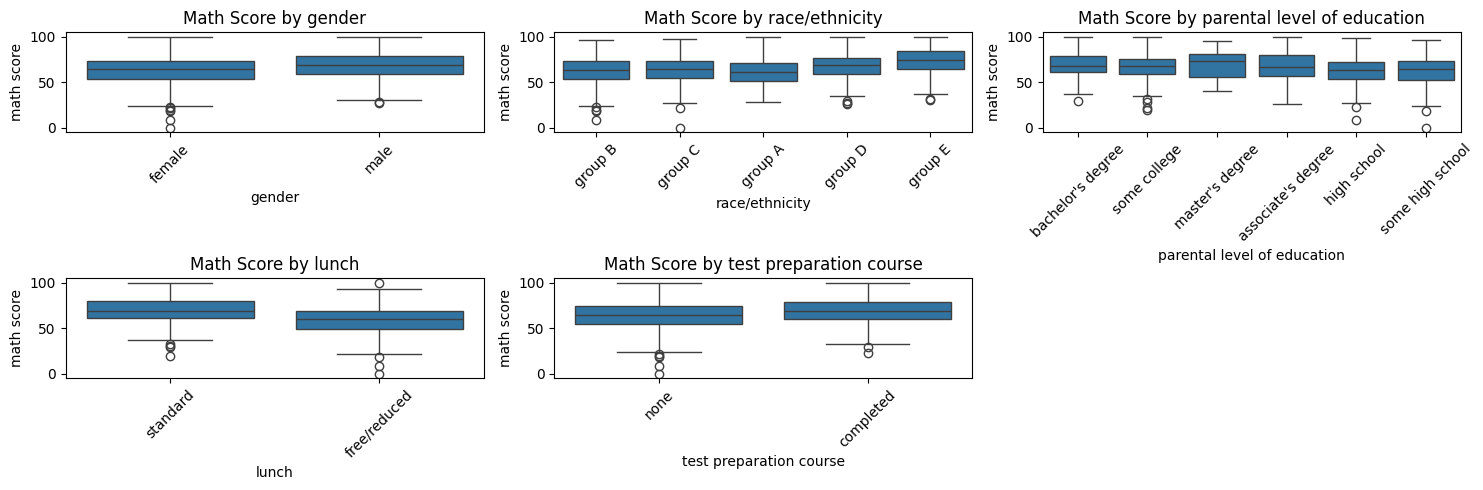

In [173]:
# 2.3 Bivariate Analysis
plt.figure(figsize=(15, 5))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=col, y='math score', data=df)
    plt.title(f'Math Score by {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Text Preprocessing


In [201]:
from sklearn.preprocessing import LabelEncoder

In [205]:
le = LabelEncoder()
for col in cat_cols:
    if col in df.columns:  # Check if column exists
        df[col] = le.fit_transform(df[col])

In [206]:
df.dtypes

gender                         int64
race/ethnicity                 int64
parental level of education    int64
lunch                          int64
test preparation course        int64
math score                     int64
reading score                  int64
writing score                  int64
pass_status                    int64
dtype: object

In [207]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,pass_status
0,0,1,1,1,1,72,72,74,1
1,0,2,4,1,0,69,90,88,1
2,0,1,3,1,1,90,95,93,1
3,1,0,0,0,1,47,57,44,1
4,1,2,4,1,1,76,78,75,1


In [208]:
# Create target variable - FIXED: Ensure this is created properly
df['pass_status'] = ((df['math score'] + df['reading score'] + df['writing score'])/3 >= 40).astype(int)

## 4. Model building


In [209]:
from sklearn.model_selection import train_test_split


In [210]:
X = df.drop(['math score', 'reading score', 'writing score', 'pass_status'], axis=1)
y = df['pass_status']

In [211]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course
0,0,1,1,1,1
1,0,2,4,1,0
2,0,1,3,1,1
3,1,0,0,0,1
4,1,2,4,1,1


In [212]:
X.dtypes

gender                         int64
race/ethnicity                 int64
parental level of education    int64
lunch                          int64
test preparation course        int64
dtype: object

In [213]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [214]:
from sklearn.preprocessing import StandardScaler


In [215]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [216]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [217]:
models = {
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}


In [218]:
# Train models
for name, model in models.items():
    model.fit(X_train_scaled, y_train)

# 5. MODEL EVALUATION

In [219]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [220]:
results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    })

In [221]:
results_df = pd.DataFrame(results)


In [222]:
results_df.sort_values('Accuracy', ascending=False)

,Model,Accuracy,Precision,Recall,F1
1,SVM,0.950,0.950000,1.000000,0.974359
4,KNN,0.950,0.950000,1.000000,0.974359
2,Logistic Regression,0.950,0.950000,1.000000,0.974359
0,Random Forest,0.945,0.949749,0.994737,0.971722
3,Decision Tree,0.945,0.949749,0.994737,0.971722


In [223]:
# Confusion Matrix for best model
best_model = RandomForestClassifier()
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

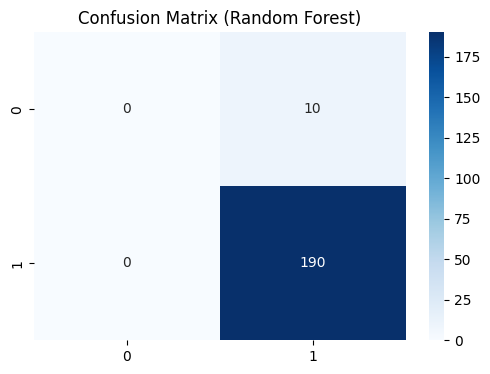

In [224]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Random Forest)')
plt.show()

In [225]:
from sklearn.model_selection import GridSearchCV

In [226]:
# Hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

In [227]:
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]})

In [228]:
grid_search.best_params_
grid_search.best_score_

np.float64(0.9725000000000001)

In [229]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': grid_search.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

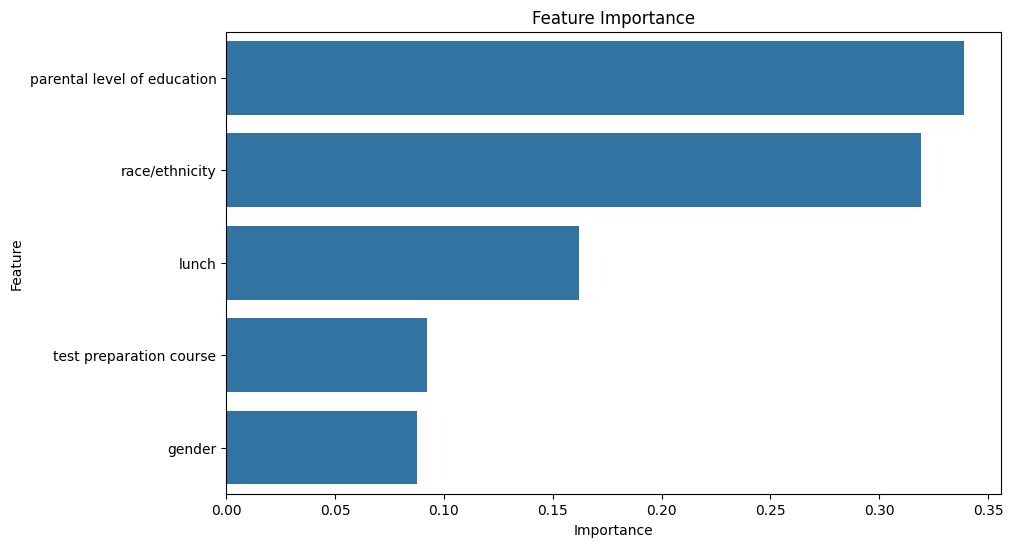

In [230]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance')
plt.show()

In [231]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE


In [232]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

In [233]:
models = {
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Gradient Boost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Optimized RF": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        random_state=42
    )
}


In [234]:
## 3. Cross-Validated Training
results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_res, y_res, cv=5, scoring='accuracy')
    model.fit(X_res, y_res)
    y_pred = model.predict(X_test_scaled)
    
    results[name] = {
        'CV Mean Accuracy': cv_scores.mean(),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    }

C:\Users\Microsoft\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:28:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Microsoft\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:28:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Microsoft\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:28:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Microsoft\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:28:26] W

In [235]:
## 4. Results Comparison
results_df = pd.DataFrame(results).T.sort_values('Test Accuracy', ascending=False)
print("\nEnhanced Model Performance:")
print(results_df)


Enhanced Model Performance:
                CV Mean Accuracy  Test Accuracy  Precision    Recall
XGBoost                 0.978205          0.935   0.949239  0.984211
Optimized RF            0.969231          0.935   0.949239  0.984211
Gradient Boost          0.969231          0.920   0.948454  0.968421
AdaBoost                0.932692          0.865   0.955307  0.900000


In [236]:
# 5. Feature Engineering (Adding Interaction Terms)
X_train['parent_edu_lunch'] = X_train['parental level of education'] * X_train['lunch']
X_test['parent_edu_lunch'] = X_test['parental level of education'] * X_test['lunch']


In [237]:
## 6. Hyperparameter Tuning (XGBoost Example)
param_grid = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'n_estimators': [100, 200]
}

grid = GridSearchCV(XGBClassifier(), param_grid, cv=3)
grid.fit(X_res, y_res)

print("\nBest XGBoost Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)



Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV Accuracy: 0.9711538461538461


In [254]:
## 7. Final Optimized Model
final_model = grid.best_estimator_
final_model.fit(X_res, y_res)
final_acc = accuracy_score(y_test, final_model.predict(X_test_scaled))
print("\nFinal Model Test Accuracy:", final_acc)



Final Model Test Accuracy: 0.935


In [253]:
import pickle

In [256]:
pickle.dump(model, open('model.pkl', 'wb'))